# 08 — Synthetic ground truth

Which explanation is right cannot be settled on real data, where the true importances
are unknown. Here the real feature matrix of the original branch is kept, with its
real correlations between lags, and a target is generated whose importances are known.

| World | True process |
|---|---|
| linear | NDVI lag 1, lag 12 and SPEI-6 enter linearly |
| switch | the same, plus a step in LST lag 1 like the one the trees found in notebook 05 |

Every other feature, including the correlated lags 11, 23 and 24, has zero true effect.
True importance is each term's share of the signal variance. The three model classes,
with their notebook 04 hyperparameters, are explained by permutation, drop-column and
SHAP over five noise draws, and each explanation is scored against the truth:

- **weighted Kendall's τ** with the true ranking
- **null mass** — the share of importance given to features with no true effect

Input: `data/processed/features_original.csv`, `results/04_best_params.json`
Output: `results/08_synthetic.csv`

In [1]:
import json
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform, weightedtau
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

MODEL_NAMES = ["XGBoost", "RandomForest", "Ridge"]
CV = TimeSeriesSplit(n_splits=5)
BASE = {"XGBoost": XGBRegressor(n_jobs=1),
        "RandomForest": RandomForestRegressor(n_jobs=-1),
        "Ridge": make_pipeline(StandardScaler(), Ridge())}


def shares(s):
    s = pd.Series(s).clip(lower=0)
    return s / s.sum()


def wtau(a, b):
    return weightedtau(np.asarray(a), np.asarray(b)).statistic


def alloc(a, b):
    return 0.5 * np.abs(shares(a).to_numpy() - shares(b).to_numpy()).sum()


def oof_permutation(model_factory, X, y, seed=0):
    folds = []
    for f, v in CV.split(X):
        m = model_factory().fit(X.iloc[f], y.iloc[f])
        r = permutation_importance(m, X.iloc[v], y.iloc[v], n_repeats=10,
                                   random_state=seed, scoring="neg_mean_squared_error")
        folds.append(r.importances_mean)
    return pd.Series(np.mean(folds, axis=0), index=X.columns)

import shap

params = json.load(open("../results/04_best_params.json"))
REPS = range(5)
TARGET_R2 = 0.85

df = pd.read_csv("../data/processed/features_original.csv", index_col="date", parse_dates=True)
X = df.drop(columns=["target", "split"])
train_rows = (df["split"] == "train").to_numpy()
Z = (X - X[train_rows].mean()) / X[train_rows].std()
print(X.shape, list(X.columns))

(274, 12) ['NDVI_lag1', 'NDVI_lag3', 'NDVI_lag11', 'NDVI_lag12', 'NDVI_lag14', 'NDVI_lag18', 'NDVI_lag23', 'NDVI_lag24', 'month_cos', 'SPEI_6_lag1', 'LST_lag1', 'noise_probe']


## The two worlds

In [2]:
def terms(world):
    t = {"NDVI_lag1": 0.6 * Z["NDVI_lag1"],
         "NDVI_lag12": 0.4 * Z["NDVI_lag12"],
         "SPEI_6_lag1": 0.3 * Z["SPEI_6_lag1"]}
    if world == "switch":
        t["LST_lag1"] = 0.8 * (Z["LST_lag1"] < 0).astype(float)
    return pd.DataFrame(t)


def truth(world):
    v = terms(world).var()
    return (v / v.sum()).reindex(X.columns, fill_value=0.0)


def simulate(world, rep):
    signal = terms(world).sum(axis=1)
    noise_sd = signal.std() * np.sqrt(1 / TARGET_R2 - 1)
    noise = np.random.default_rng(100 + rep).normal(0, noise_sd, len(signal))
    y = signal + noise
    return 0.45 + 0.15 * (y - y.mean()) / y.std()


for world in ["linear", "switch"]:
    print(f"{world:7s} true shares:",
          {k: round(v, 3) for k, v in truth(world).items() if v > 0})

linear  true shares: {'NDVI_lag1': 0.577, 'NDVI_lag12': 0.255, 'SPEI_6_lag1': 0.168}
switch  true shares: {'NDVI_lag1': 0.457, 'NDVI_lag12': 0.203, 'SPEI_6_lag1': 0.133, 'LST_lag1': 0.207}


## Explanations against the truth

In [3]:
def make_model(name, seed):
    est = clone(BASE[name]).set_params(**params[f"original|{name}"])
    if name != "Ridge":
        est.set_params(random_state=seed)
    return est


def oof_mse(name, cols, Xt, yt, seed):
    return np.mean([np.mean((yt.iloc[v] - make_model(name, seed).fit(Xt[cols].iloc[f], yt.iloc[f])
                                          .predict(Xt[cols].iloc[v])) ** 2)
                    for f, v in CV.split(Xt)])


def explain(name, Xt, yt, seed):
    perm = oof_permutation(lambda: make_model(name, seed), Xt, yt, seed)
    cols = list(Xt.columns)
    full = oof_mse(name, cols, Xt, yt, seed)
    drop = pd.Series({c: oof_mse(name, [k for k in cols if k != c], Xt, yt, seed) / full - 1
                      for c in cols})
    model = make_model(name, seed).fit(Xt, yt)
    bg = Xt.sample(100, random_state=0)
    explainer = shap.PermutationExplainer(model.predict,
                                          shap.maskers.Independent(bg, max_samples=len(bg)),
                                          seed=0)
    sv = explainer(Xt, silent=True).values
    return {"permutation": perm, "drop-column": drop,
            "SHAP": pd.Series(np.abs(sv).mean(axis=0), index=cols)}


rows = []
for world in ["linear", "switch"]:
    true = truth(world)
    null = true.index[true == 0]
    lst_true = true["LST_lag1"]
    for rep in REPS:
        y = simulate(world, rep)
        Xt, yt = X[train_rows], y[train_rows]
        for name in MODEL_NAMES:
            for method, imp in explain(name, Xt, yt, rep).items():
                s = shares(imp)
                rows.append(dict(world=world, rep=rep, model=name, method=method,
                                 tau=wtau(imp, true), null_mass=s[null].sum(),
                                 LST_share=s["LST_lag1"], LST_true=lst_true))

synthetic = pd.DataFrame(rows)
summary = (synthetic.groupby(["world", "model", "method"])
                    [["tau", "null_mass", "LST_share", "LST_true"]].mean())
print(summary.round(3).to_string())

                                   tau  null_mass  LST_share  LST_true
world  model        method                                            
linear RandomForest SHAP         0.665      0.401      0.217     0.000
                    drop-column  0.653      0.062      0.008     0.000
                    permutation  0.665      0.274      0.230     0.000
       Ridge        SHAP         0.817      0.264      0.040     0.000
                    drop-column  0.663      0.018      0.003     0.000
                    permutation  0.817      0.136      0.035     0.000
       XGBoost      SHAP         0.756      0.353      0.159     0.000
                    drop-column  0.663      0.086      0.013     0.000
                    permutation  0.726      0.197      0.161     0.000
switch RandomForest SHAP         0.787      0.180      0.338     0.207
                    drop-column  0.619      0.095      0.056     0.207
                    permutation  0.772      0.035      0.463     0.207
      

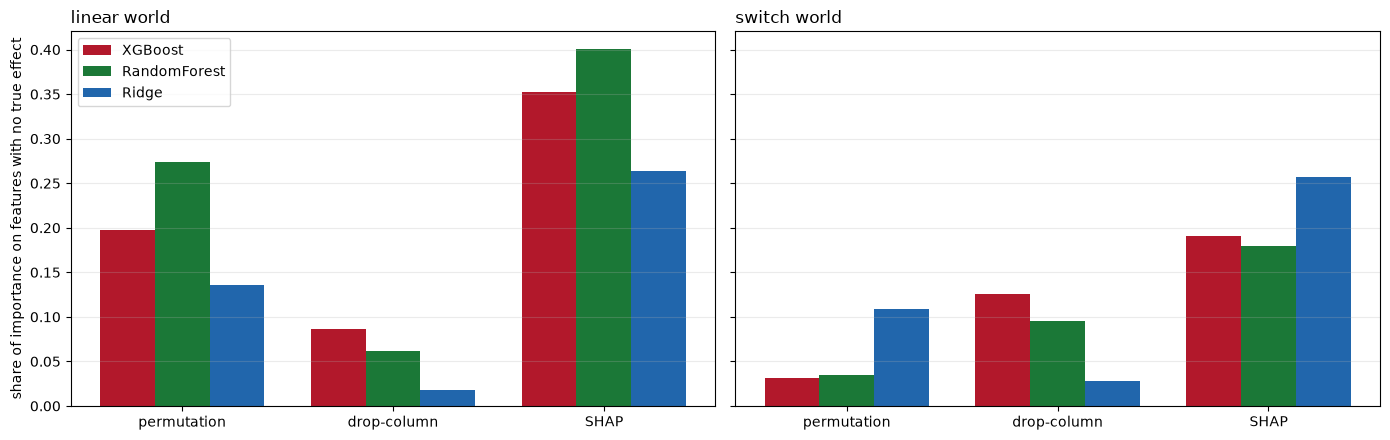

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
methods = ["permutation", "drop-column", "SHAP"]
colors = {"XGBoost": "#b2182b", "RandomForest": "#1b7837", "Ridge": "#2166ac"}
for ax, world in zip(axes, ["linear", "switch"]):
    for i, name in enumerate(MODEL_NAMES):
        sub = summary.loc[(world, name)].reindex(methods)
        ax.bar(np.arange(3) + (i - 1) * 0.26, sub["null_mass"], width=0.26,
               color=colors[name], label=name)
    ax.set_xticks(range(3), methods)
    ax.set_title(f"{world} world", loc="left")
    ax.grid(alpha=0.25, axis="y")
axes[0].set_ylabel("share of importance on features with no true effect")
axes[0].legend()
fig.tight_layout()
fig.savefig("../figures/08_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

In [5]:
synthetic.to_csv("../results/08_synthetic.csv", index=False)
print("saved")

saved
